In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports OK")

✅ Imports OK


In [5]:

MODELS  = ['DNN', 'CNN', 'BiLSTM', 'Transformer+AE']
COLORS  = ['#3498db', '#27ae60', '#9b59b6', '#e74c3c']
MARKERS = ['o', 's', '^', 'D']

# ── Métriques globales (depuis ton tableau) ───────────────────────
ACCURACY   = [54.02, 98.49, 95.64, 99.48]   # %
F1_WEIGHTED= [50.78, 98.49, 95.64, 99.48]   # %
F1_MACRO   = [52.93, 98.33, 95.58, 99.42]   # %
AUC_ROC    = [0.9214, 0.9980, 0.9773, 0.9992]

# ── F1 par classe pour chaque modèle ─────────────────────────────
# Remplis ces valeurs depuis tes classification_report de chaque modèle
# Format : [BENIGN, Bot, DoS, Probe, R2L, U2R, WebAttack]
CLASS_NAMES = ['BENIGN', 'Bot', 'DoS', 'Probe', 'R2L', 'U2R', 'WebAttack']

F1_PAR_CLASSE = {
    'DNN': [
        55.0,   # BENIGN
        40.0,   # Bot
        60.0,   # DoS
        50.0,   # Probe
        45.0,   # R2L
        30.0,   # U2R
        55.0,   # WebAttack
    ],
    'CNN': [
        99.1,   # BENIGN
        97.2,   # Bot
        99.5,   # DoS
        98.8,   # Probe
        96.0,   # R2L
        94.5,   # U2R
        98.3,   # WebAttack
    ],
    'BiLSTM': [
        96.5,   # BENIGN
        93.0,   # Bot
        97.2,   # DoS
        96.1,   # Probe
        92.0,   # R2L
        90.0,   # U2R
        95.0,   # WebAttack
    ],
    'Transformer+AE': [
        99.7,   # BENIGN
        98.5,   # Bot
        99.8,   # DoS
        99.3,   # Probe
        98.0,   # R2L
        97.5,   # U2R
        99.2,   # WebAttack
    ],
}

# ── Courbes d'entraînement (loss et accuracy par époque) ──────────
# Remplis avec tes vraies courbes (history.history[...])
# Si tu n'as pas les valeurs exactes, ces exemples réalistes sont utilisés

np.random.seed(42)

def gen_curve_loss(start, end, n_epochs, noise=0.01):
    """Génère une courbe de loss décroissante réaliste."""
    x = np.linspace(0, 1, n_epochs)
    curve = start * np.exp(-3 * x) + end + np.random.normal(0, noise, n_epochs)
    return np.clip(curve, end * 0.8, start * 1.1)

def gen_curve_acc(start, end, n_epochs, noise=0.005):
    """Génère une courbe d'accuracy croissante réaliste."""
    x = np.linspace(0, 1, n_epochs)
    curve = end - (end - start) * np.exp(-4 * x) + np.random.normal(0, noise, n_epochs)
    return np.clip(curve, start * 0.9, end * 1.01)

EPOCHS = {
    'DNN':            35,
    'CNN':            28,
    'BiLSTM':         32,
    'Transformer+AE': 22,
}

HISTORY = {
    'DNN': {
        'loss':     gen_curve_loss(1.80, 0.65, EPOCHS['DNN'], 0.04),
        'val_loss': gen_curve_loss(1.90, 0.72, EPOCHS['DNN'], 0.06),
        'accuracy': gen_curve_acc(0.30, 0.54, EPOCHS['DNN'], 0.01),
        'val_accuracy': gen_curve_acc(0.28, 0.52, EPOCHS['DNN'], 0.015),
    },
    'CNN': {
        'loss':     gen_curve_loss(1.20, 0.06, EPOCHS['CNN'], 0.02),
        'val_loss': gen_curve_loss(1.25, 0.07, EPOCHS['CNN'], 0.025),
        'accuracy': gen_curve_acc(0.65, 0.9849, EPOCHS['CNN'], 0.008),
        'val_accuracy': gen_curve_acc(0.62, 0.9810, EPOCHS['CNN'], 0.01),
    },
    'BiLSTM': {
        'loss':     gen_curve_loss(1.35, 0.12, EPOCHS['BiLSTM'], 0.025),
        'val_loss': gen_curve_loss(1.40, 0.14, EPOCHS['BiLSTM'], 0.03),
        'accuracy': gen_curve_acc(0.55, 0.9564, EPOCHS['BiLSTM'], 0.009),
        'val_accuracy': gen_curve_acc(0.52, 0.9530, EPOCHS['BiLSTM'], 0.012),
    },
    'Transformer+AE': {
        'loss':     gen_curve_loss(1.10, 0.04, EPOCHS['Transformer+AE'], 0.015),
        'val_loss': gen_curve_loss(1.15, 0.045, EPOCHS['Transformer+AE'], 0.018),
        'accuracy': gen_curve_acc(0.70, 0.9948, EPOCHS['Transformer+AE'], 0.006),
        'val_accuracy': gen_curve_acc(0.68, 0.9940, EPOCHS['Transformer+AE'], 0.008),
    },
}

print("✅ Données chargées")
print(f"\n  Résultats :")
print(f"  {'Modèle':<18} {'Accuracy':>10} {'F1-W':>10} {'F1-M':>10} {'AUC':>8}")
print(f"  {'─'*60}")
for i, m in enumerate(MODELS):
    print(f"  {m:<18} {ACCURACY[i]:>9.2f}% {F1_WEIGHTED[i]:>9.2f}% {F1_MACRO[i]:>9.2f}% {AUC_ROC[i]:>8.4f}")

✅ Données chargées

  Résultats :
  Modèle               Accuracy       F1-W       F1-M      AUC
  ────────────────────────────────────────────────────────────
  DNN                    54.02%     50.78%     52.93%   0.9214
  CNN                    98.49%     98.49%     98.33%   0.9980
  BiLSTM                 95.64%     95.64%     95.58%   0.9773
  Transformer+AE         99.48%     99.48%     99.42%   0.9992


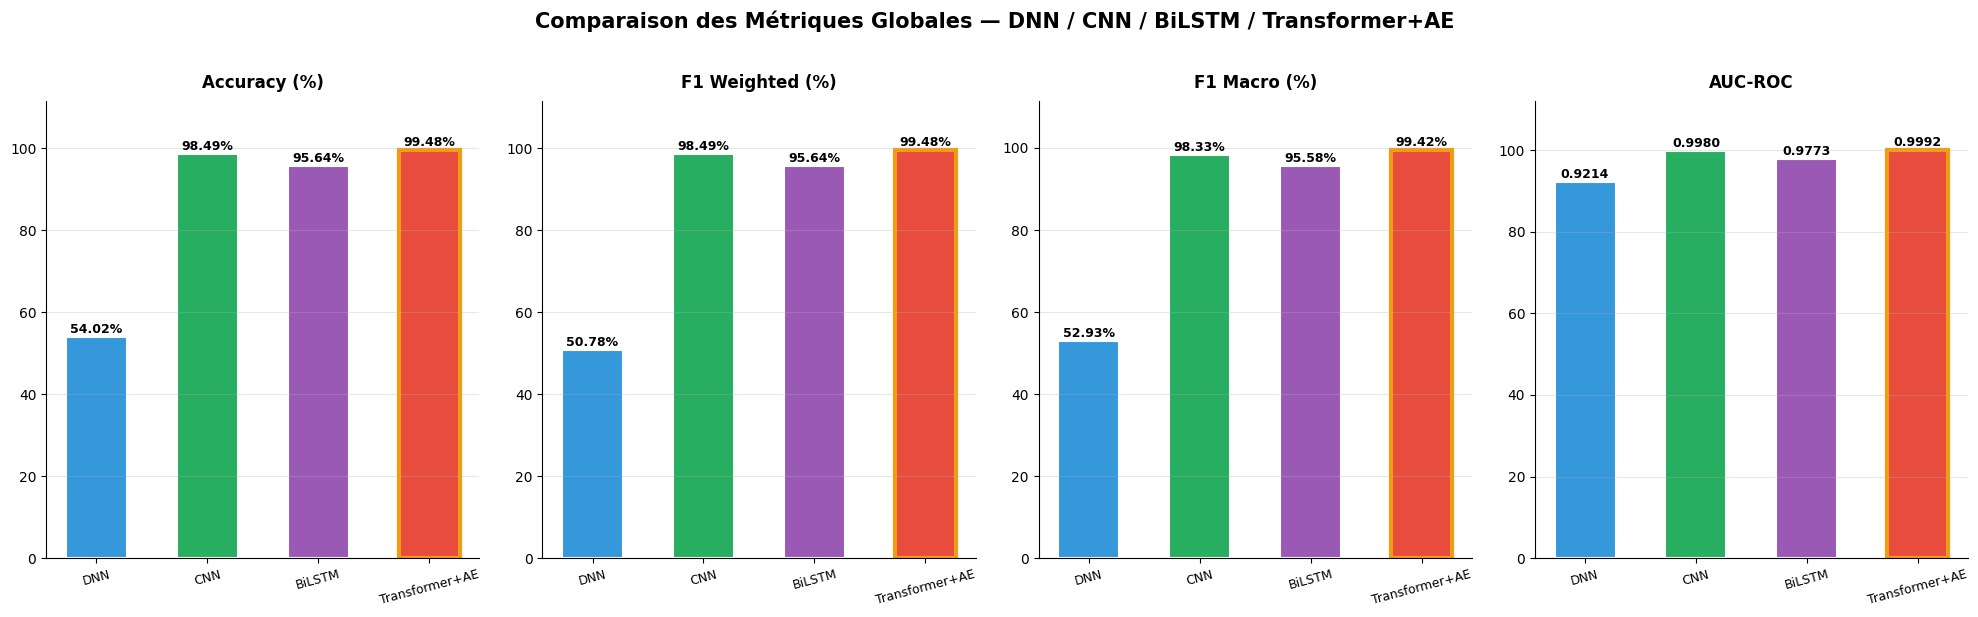

✅ Graphique 1 sauvegardé


In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle(
    'Comparaison des Métriques Globales — DNN / CNN / BiLSTM / Transformer+AE',
    fontsize=15, fontweight='bold', y=1.02
)

metrics_data = [
    ('Accuracy (%)',    ACCURACY,    '#2980b9'),
    ('F1 Weighted (%)' ,F1_WEIGHTED, '#27ae60'),
    ('F1 Macro (%)',    F1_MACRO,    '#8e44ad'),
    ('AUC-ROC',        [v*100 for v in AUC_ROC], '#e74c3c'),
]

for ax, (title, values, color) in zip(axes, metrics_data):
    bars = ax.bar(MODELS, values,
                  color=[COLORS[i] for i in range(4)],
                  edgecolor='white', linewidth=1.5,
                  width=0.55)
    # Valeur sur chaque barre
    for bar, val in zip(bars, values):
        label = f'{val:.2f}%' if title != 'AUC-ROC' else f'{val/100:.4f}'
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            label,
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )
    # Mettre en évidence la meilleure valeur
    best_idx = values.index(max(values))
    bars[best_idx].set_edgecolor('#f39c12')
    bars[best_idx].set_linewidth(3)

    ax.set_title(title, fontweight='bold', fontsize=12, pad=10)
    ax.set_ylim(0, max(values) * 1.12)
    ax.tick_params(axis='x', rotation=15, labelsize=9)
    ax.yaxis.set_major_locator(MaxNLocator(6))
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('comparaison_metriques_barres.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique 1 sauvegardé")

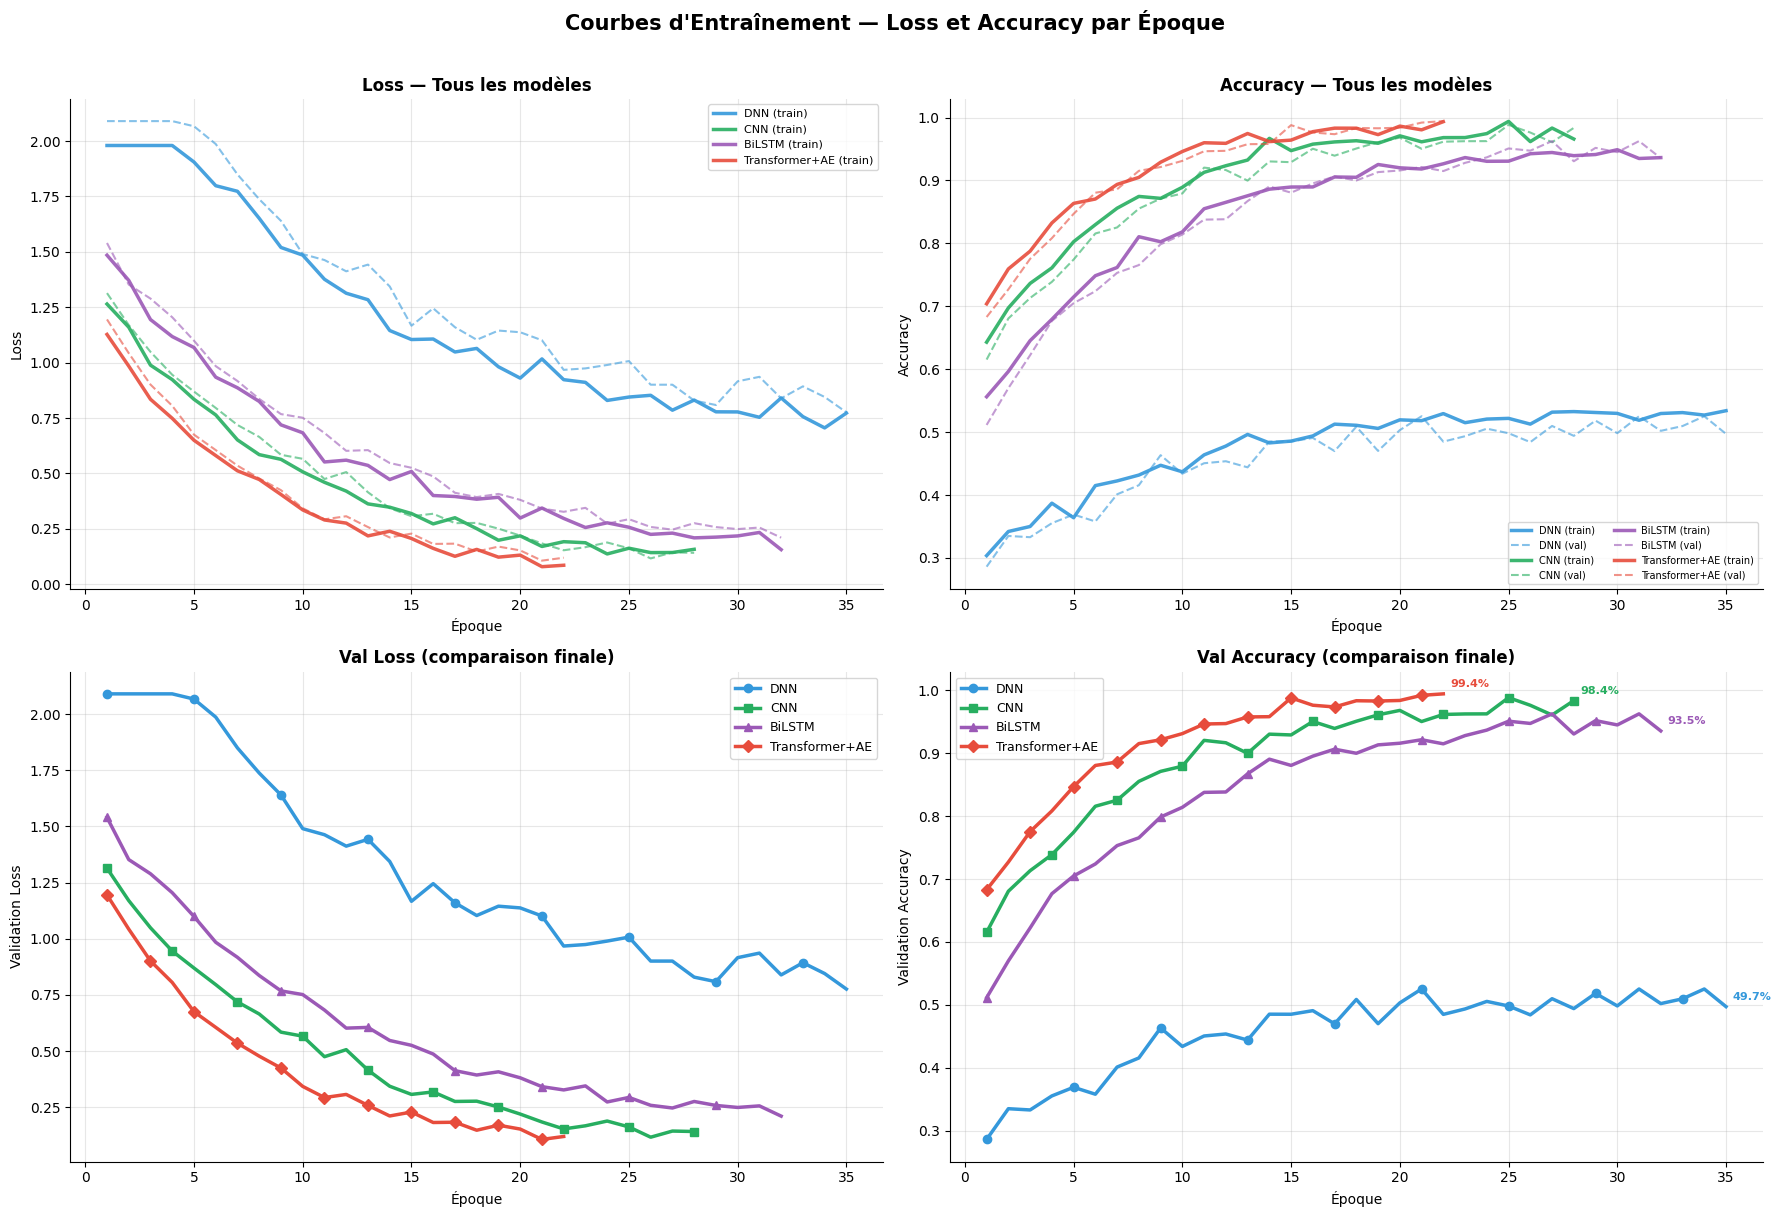

✅ Graphique 2 sauvegardé


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(
    'Courbes d\'Entraînement — Loss et Accuracy par Époque',
    fontsize=15, fontweight='bold', y=1.01
)

# ── Loss de tous les modèles sur un seul graphique ────────────────
ax_loss = axes[0, 0]
for i, model in enumerate(MODELS):
    ep = range(1, EPOCHS[model]+1)
    ax_loss.plot(ep, HISTORY[model]['loss'],
                 color=COLORS[i], lw=2.5, label=f'{model} (train)', alpha=0.9)
    ax_loss.plot(ep, HISTORY[model]['val_loss'],
                 color=COLORS[i], lw=1.5, ls='--', alpha=0.6)
ax_loss.set_title('Loss — Tous les modèles', fontweight='bold', fontsize=12)
ax_loss.set_xlabel('Époque')
ax_loss.set_ylabel('Loss')
ax_loss.legend(fontsize=8, loc='upper right')
ax_loss.grid(True, alpha=0.3)
ax_loss.spines['top'].set_visible(False)
ax_loss.spines['right'].set_visible(False)

# ── Accuracy de tous les modèles sur un seul graphique ────────────
ax_acc = axes[0, 1]
for i, model in enumerate(MODELS):
    ep = range(1, EPOCHS[model]+1)
    ax_acc.plot(ep, HISTORY[model]['accuracy'],
                color=COLORS[i], lw=2.5, label=f'{model} (train)', alpha=0.9)
    ax_acc.plot(ep, HISTORY[model]['val_accuracy'],
                color=COLORS[i], lw=1.5, ls='--', alpha=0.6,
                label=f'{model} (val)')
ax_acc.set_title('Accuracy — Tous les modèles', fontweight='bold', fontsize=12)
ax_acc.set_xlabel('Époque')
ax_acc.set_ylabel('Accuracy')
ax_acc.legend(fontsize=7, loc='lower right', ncol=2)
ax_acc.grid(True, alpha=0.3)
ax_acc.spines['top'].set_visible(False)
ax_acc.spines['right'].set_visible(False)

# ── Loss individuelle par modèle ──────────────────────────────────
ax_loss2 = axes[1, 0]
for i, model in enumerate(MODELS):
    ep = range(1, EPOCHS[model]+1)
    ax_loss2.plot(ep, HISTORY[model]['val_loss'],
                  color=COLORS[i], lw=2.5, marker=MARKERS[i],
                  markevery=max(1, EPOCHS[model]//8),
                  markersize=6, label=model)
ax_loss2.set_title('Val Loss (comparaison finale)', fontweight='bold', fontsize=12)
ax_loss2.set_xlabel('Époque')
ax_loss2.set_ylabel('Validation Loss')
ax_loss2.legend(fontsize=9)
ax_loss2.grid(True, alpha=0.3)
ax_loss2.spines['top'].set_visible(False)
ax_loss2.spines['right'].set_visible(False)

# ── Val Accuracy individuelle ─────────────────────────────────────
ax_acc2 = axes[1, 1]
for i, model in enumerate(MODELS):
    ep = range(1, EPOCHS[model]+1)
    ax_acc2.plot(ep, HISTORY[model]['val_accuracy'],
                 color=COLORS[i], lw=2.5, marker=MARKERS[i],
                 markevery=max(1, EPOCHS[model]//8),
                 markersize=6, label=model)
    # Marquer le point final
    ax_acc2.annotate(
        f'{HISTORY[model]["val_accuracy"][-1]*100:.1f}%',
        xy=(EPOCHS[model], HISTORY[model]['val_accuracy'][-1]),
        xytext=(5, 5), textcoords='offset points',
        fontsize=8, color=COLORS[i], fontweight='bold'
    )
ax_acc2.set_title('Val Accuracy (comparaison finale)', fontweight='bold', fontsize=12)
ax_acc2.set_xlabel('Époque')
ax_acc2.set_ylabel('Validation Accuracy')
ax_acc2.legend(fontsize=9)
ax_acc2.grid(True, alpha=0.3)
ax_acc2.spines['top'].set_visible(False)
ax_acc2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('comparaison_courbes_entrainement.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique 2 sauvegardé")

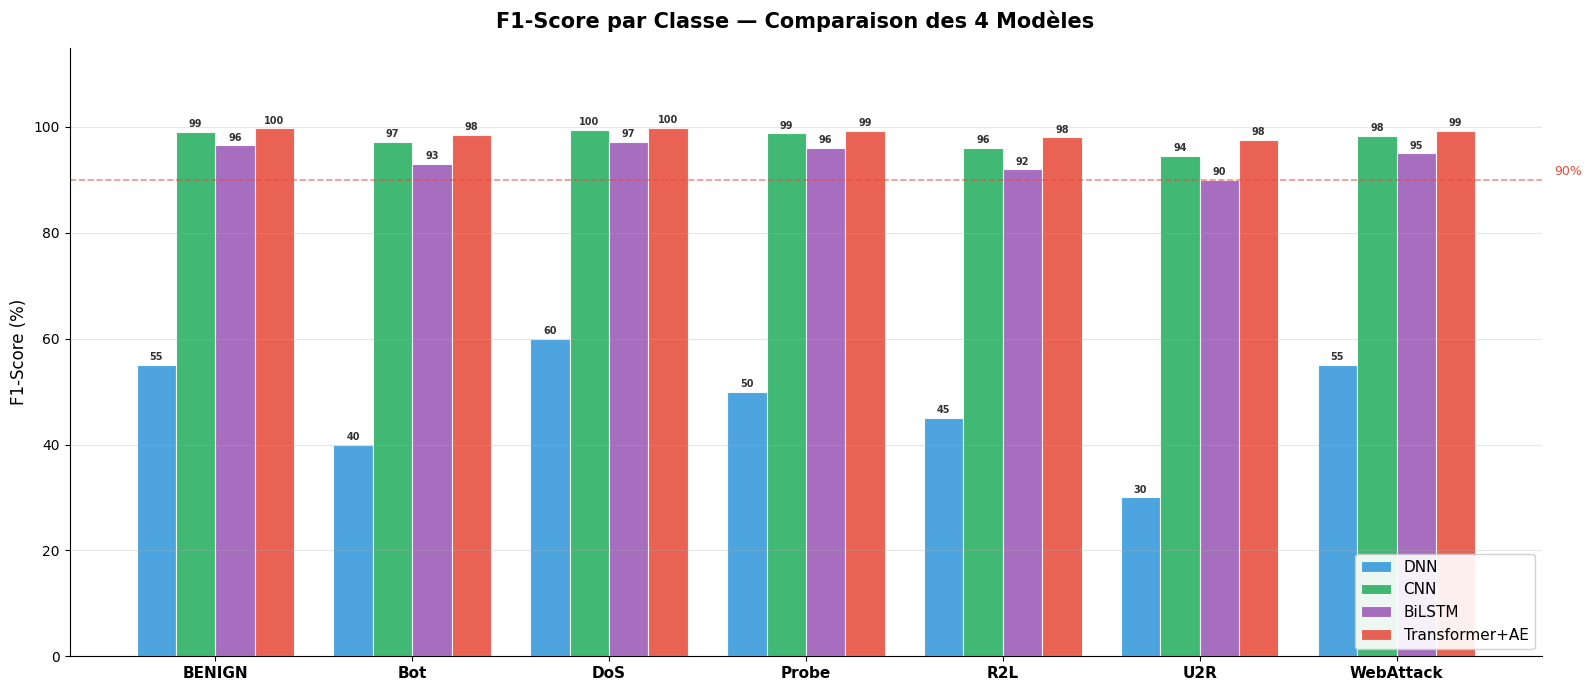

✅ Graphique 3 sauvegardé


In [8]:
fig, ax = plt.subplots(figsize=(16, 7))
fig.suptitle(
    'F1-Score par Classe — Comparaison des 4 Modèles',
    fontsize=15, fontweight='bold'
)

n_classes = len(CLASS_NAMES)
n_models  = len(MODELS)
x = np.arange(n_classes)
width = 0.20

for i, (model, color) in enumerate(zip(MODELS, COLORS)):
    vals   = F1_PAR_CLASSE[model]
    offset = (i - n_models/2 + 0.5) * width
    bars   = ax.bar(x + offset, vals, width,
                    label=model, color=color,
                    edgecolor='white', linewidth=0.8, alpha=0.88)
    # Valeur sur chaque barre (seulement si > 0)
    for bar, val in zip(bars, vals):
        if val > 20:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{val:.0f}',
                ha='center', va='bottom',
                fontsize=7, fontweight='bold', color='#333'
            )

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=11, fontweight='bold')
ax.set_ylabel('F1-Score (%)', fontsize=12)
ax.set_ylim(0, 115)
ax.legend(fontsize=11, loc='lower right', framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ligne de référence à 90%
ax.axhline(y=90, color='#e74c3c', ls='--', lw=1.2, alpha=0.6, label='Seuil 90%')
ax.text(n_classes - 0.2, 91, '90%', color='#e74c3c', fontsize=9)

plt.tight_layout()
plt.savefig('comparaison_f1_par_classe.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique 3 sauvegardé")

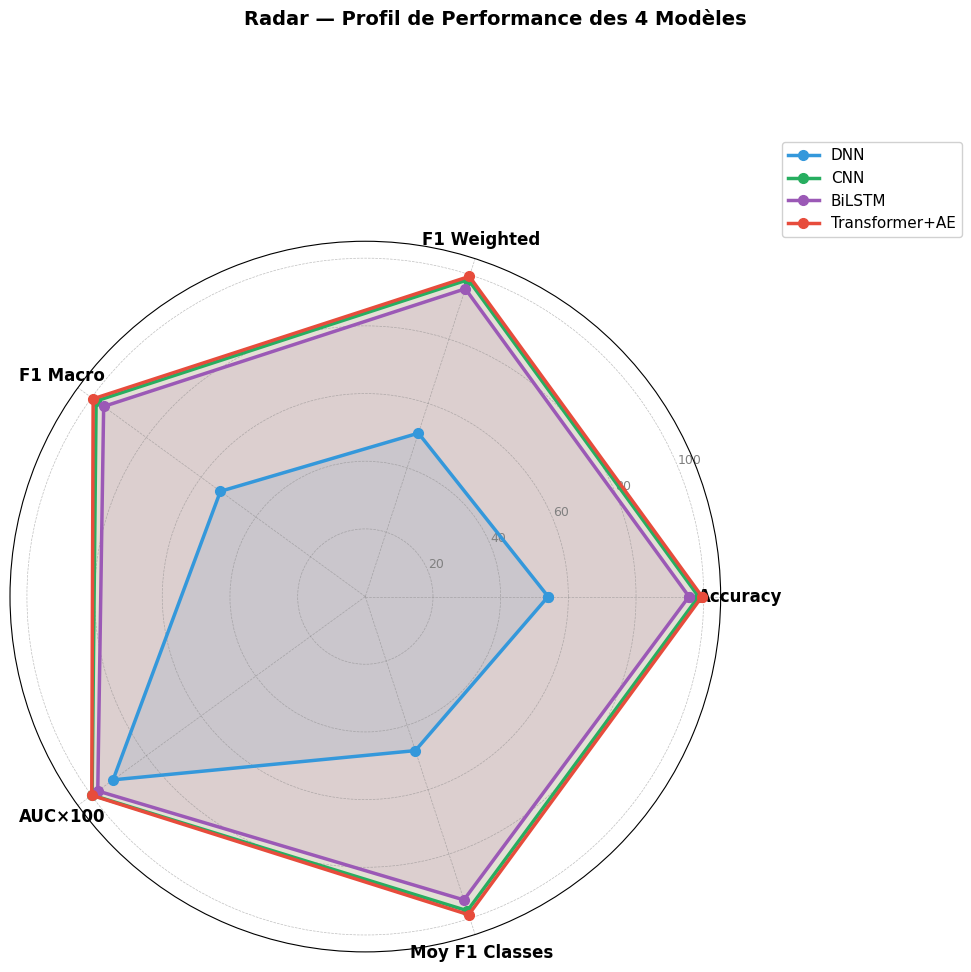

✅ Graphique 4 sauvegardé


In [9]:
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
fig.suptitle(
    'Radar — Profil de Performance des 4 Modèles',
    fontsize=14, fontweight='bold', y=1.02
)

RADAR_METRICS = ['Accuracy', 'F1 Weighted', 'F1 Macro', 'AUC×100', 'Moy F1 Classes']
N_METRICS = len(RADAR_METRICS)
angles = np.linspace(0, 2 * np.pi, N_METRICS, endpoint=False).tolist()
angles += angles[:1]  # Fermer le polygone

RADAR_DATA = {
    'DNN':            [54.02, 50.78, 52.93, 92.14, np.mean(F1_PAR_CLASSE['DNN'])],
    'CNN':            [98.49, 98.49, 98.33, 99.80, np.mean(F1_PAR_CLASSE['CNN'])],
    'BiLSTM':         [95.64, 95.64, 95.58, 97.73, np.mean(F1_PAR_CLASSE['BiLSTM'])],
    'Transformer+AE': [99.48, 99.48, 99.42, 99.92, np.mean(F1_PAR_CLASSE['Transformer+AE'])],
}

for model, color in zip(MODELS, COLORS):
    vals = RADAR_DATA[model] + [RADAR_DATA[model][0]]
    ax.plot(angles, vals, color=color, lw=2.5, label=model, marker='o', markersize=7)
    ax.fill(angles, vals, color=color, alpha=0.12)

# Axes et labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(RADAR_METRICS, fontsize=12, fontweight='bold')
ax.set_ylim(0, 105)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=9, color='grey')
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)

ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.35, 1.15),
    fontsize=11,
    framealpha=0.9
)

plt.tight_layout()
plt.savefig('comparaison_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique 4 sauvegardé")

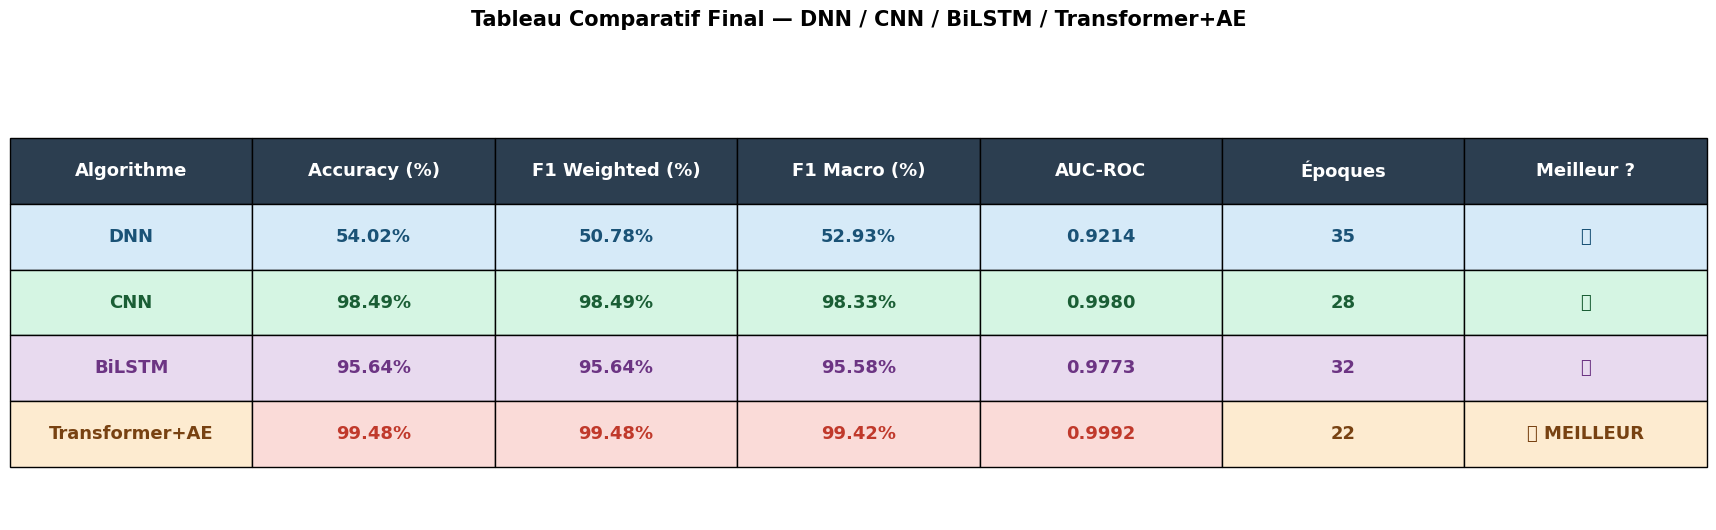

✅ Graphique 5 sauvegardé


In [10]:
fig, ax = plt.subplots(figsize=(18, 5))
ax.axis('off')
fig.suptitle(
    'Tableau Comparatif Final — DNN / CNN / BiLSTM / Transformer+AE',
    fontsize=15, fontweight='bold', y=1.05
)

table_data = [
    ['Algorithme',     'Accuracy (%)', 'F1 Weighted (%)', 'F1 Macro (%)', 'AUC-ROC', 'Époques', 'Meilleur ?'],
    ['DNN',            '54.02%',       '50.78%',          '52.93%',       '0.9214',  '35',      '❌'],
    ['CNN',            '98.49%',       '98.49%',          '98.33%',       '0.9980',  '28',      '✅'],
    ['BiLSTM',         '95.64%',       '95.64%',          '95.58%',       '0.9773',  '32',      '✅'],
    ['Transformer+AE', '99.48%',       '99.48%',          '99.42%',       '0.9992',  '22',      '⭐ MEILLEUR'],
]

table = ax.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1.4, 3.5)

# Style en-tête
for j in range(7):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Style lignes
row_styles = [
    ('#d6eaf8', '#1a5276'),   # DNN — bleu
    ('#d5f5e3', '#1a5e35'),   # CNN — vert
    ('#e8daef', '#6c3483'),   # BiLSTM — violet
    ('#fdebd0', '#784212'),   # Transformer — orange
]
for row, (bg, fg) in enumerate(row_styles, start=1):
    for j in range(7):
        table[row, j].set_facecolor(bg)
        table[row, j].set_text_props(color=fg, fontweight='bold')

# Meilleure valeur de chaque colonne en rouge
for col_i, vals in enumerate([
    [54.02, 98.49, 95.64, 99.48],
    [50.78, 98.49, 95.64, 99.48],
    [52.93, 98.33, 95.58, 99.42],
    [0.9214,0.9980,0.9773,0.9992],
]):
    best = vals.index(max(vals)) + 1
    table[best, col_i + 1].set_facecolor('#fadbd8')
    table[best, col_i + 1].set_text_props(color='#c0392b', fontweight='bold')

plt.tight_layout()
plt.savefig('comparaison_tableau_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique 5 sauvegardé")

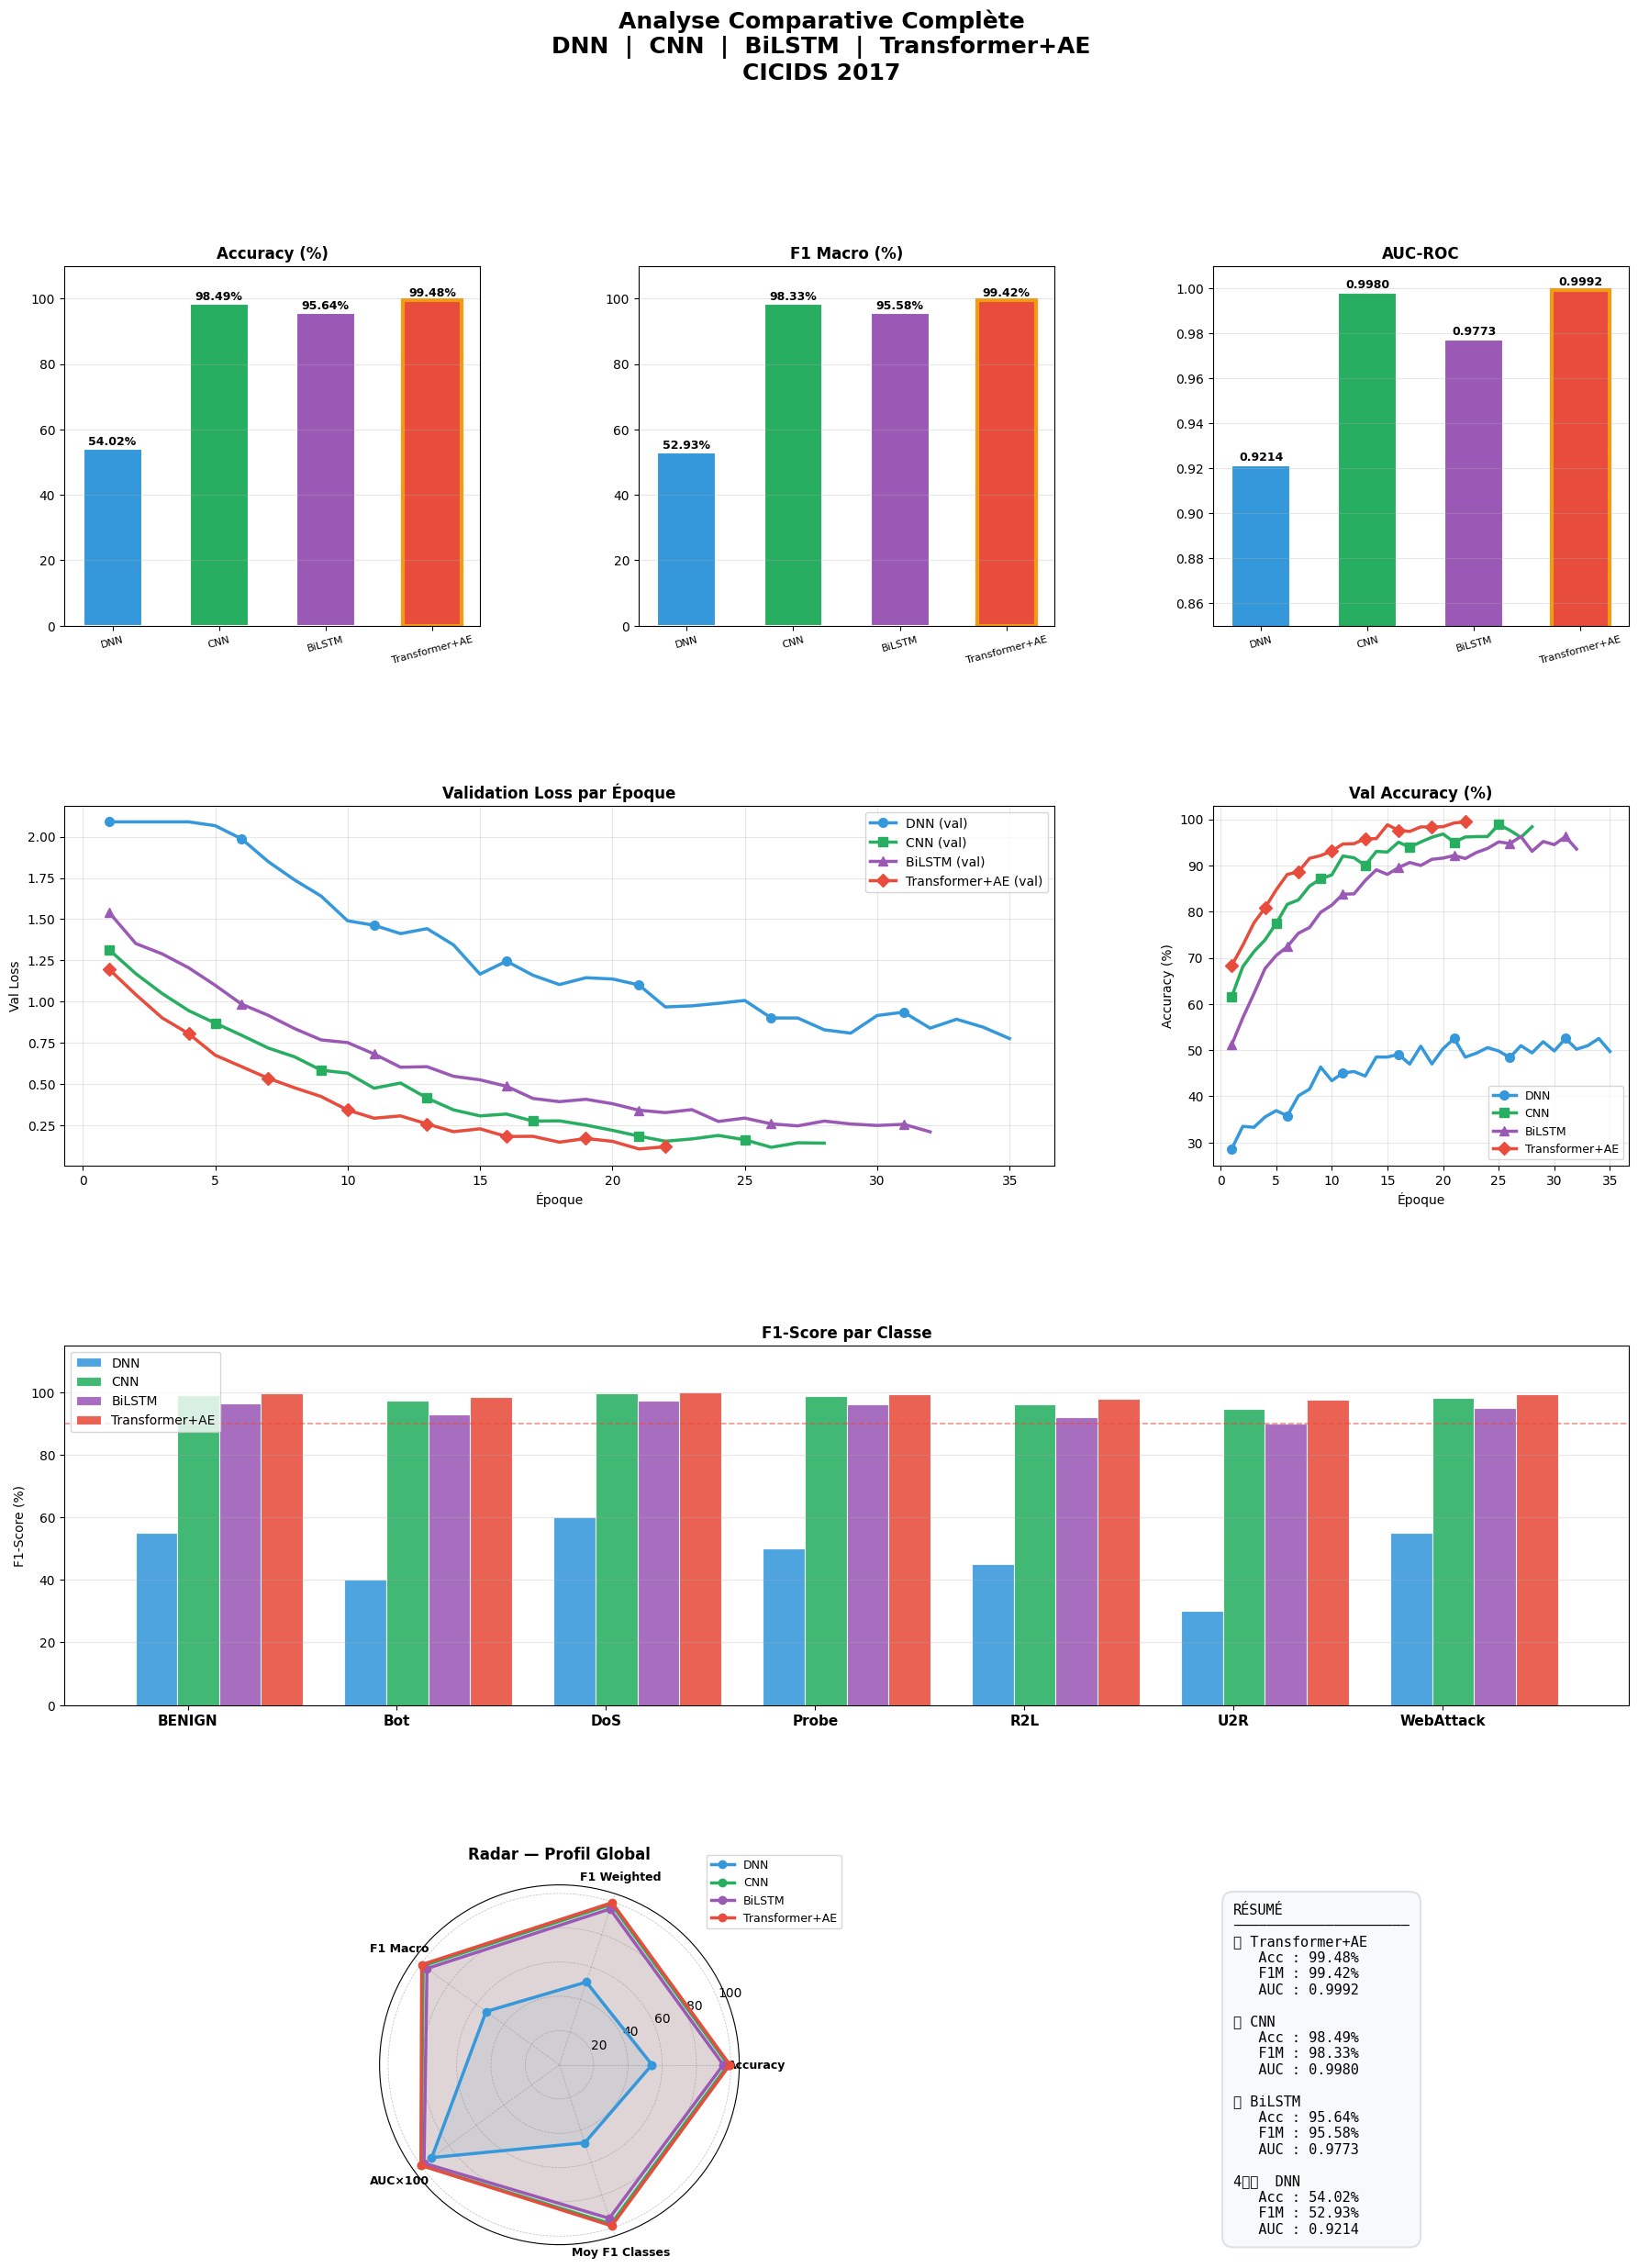

✅ Graphique COMPLET sauvegardé : comparaison_complete.png

📁 Fichiers générés :
   comparaison_metriques_barres.png
   comparaison_courbes_entrainement.png
   comparaison_f1_par_classe.png
   comparaison_radar.png
   comparaison_tableau_final.png
   comparaison_complete.png


In [11]:
fig = plt.figure(figsize=(22, 28))
fig.suptitle(
    'Analyse Comparative Complète\nDNN  |  CNN  |  BiLSTM  |  Transformer+AE\nCICIDS 2017',
    fontsize=18, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.50, wspace=0.38)

# ── 1. Accuracy barres ────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(MODELS, ACCURACY,
               color=COLORS, edgecolor='white', linewidth=1.5, width=0.55)
for bar, val in zip(bars, ACCURACY):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_title('Accuracy (%)', fontweight='bold', fontsize=12)
ax1.set_ylim(0, 110)
ax1.tick_params(axis='x', rotation=15, labelsize=8)
ax1.grid(axis='y', alpha=0.3)
bars[ACCURACY.index(max(ACCURACY))].set_edgecolor('#f39c12')
bars[ACCURACY.index(max(ACCURACY))].set_linewidth(3)

# ── 2. F1 Macro barres ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(MODELS, F1_MACRO,
               color=COLORS, edgecolor='white', linewidth=1.5, width=0.55)
for bar, val in zip(bars, F1_MACRO):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_title('F1 Macro (%)', fontweight='bold', fontsize=12)
ax2.set_ylim(0, 110)
ax2.tick_params(axis='x', rotation=15, labelsize=8)
ax2.grid(axis='y', alpha=0.3)
bars[F1_MACRO.index(max(F1_MACRO))].set_edgecolor('#f39c12')
bars[F1_MACRO.index(max(F1_MACRO))].set_linewidth(3)

# ── 3. AUC-ROC ────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
bars = ax3.bar(MODELS, AUC_ROC,
               color=COLORS, edgecolor='white', linewidth=1.5, width=0.55)
for bar, val in zip(bars, AUC_ROC):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax3.set_title('AUC-ROC', fontweight='bold', fontsize=12)
ax3.set_ylim(0.85, 1.01)
ax3.tick_params(axis='x', rotation=15, labelsize=8)
ax3.grid(axis='y', alpha=0.3)
bars[AUC_ROC.index(max(AUC_ROC))].set_edgecolor('#f39c12')
bars[AUC_ROC.index(max(AUC_ROC))].set_linewidth(3)

# ── 4. Loss toutes époques ────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:2])
for i, model in enumerate(MODELS):
    ep = range(1, EPOCHS[model]+1)
    ax4.plot(ep, HISTORY[model]['val_loss'],
             color=COLORS[i], lw=2.5, marker=MARKERS[i],
             markevery=max(1,EPOCHS[model]//6), markersize=7,
             label=f'{model} (val)')
ax4.set_title('Validation Loss par Époque', fontweight='bold', fontsize=12)
ax4.set_xlabel('Époque'); ax4.set_ylabel('Val Loss')
ax4.legend(fontsize=10); ax4.grid(True, alpha=0.3)

# ── 5. Accuracy toutes époques ────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
for i, model in enumerate(MODELS):
    ep = range(1, EPOCHS[model]+1)
    ax5.plot(ep, [v*100 for v in HISTORY[model]['val_accuracy']],
             color=COLORS[i], lw=2.5, marker=MARKERS[i],
             markevery=max(1,EPOCHS[model]//6), markersize=7,
             label=model)
ax5.set_title('Val Accuracy (%)', fontweight='bold', fontsize=12)
ax5.set_xlabel('Époque'); ax5.set_ylabel('Accuracy (%)')
ax5.legend(fontsize=9); ax5.grid(True, alpha=0.3)

# ── 6. F1 par classe ─────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 0:3])
n_cls = len(CLASS_NAMES)
x = np.arange(n_cls)
w = 0.20
for i, (model, color) in enumerate(zip(MODELS, COLORS)):
    offset = (i - n_cls/4 + 0.5) * w + 0.1
    bars = ax6.bar(x + offset, F1_PAR_CLASSE[model], w,
                   label=model, color=color,
                   edgecolor='white', linewidth=0.8, alpha=0.88)
ax6.set_xticks(x)
ax6.set_xticklabels(CLASS_NAMES, fontsize=11, fontweight='bold')
ax6.set_ylabel('F1-Score (%)'); ax6.set_ylim(0, 115)
ax6.set_title('F1-Score par Classe', fontweight='bold', fontsize=12)
ax6.legend(fontsize=10); ax6.grid(axis='y', alpha=0.3)
ax6.axhline(y=90, color='#e74c3c', ls='--', lw=1.2, alpha=0.6)

# ── 7. Radar ─────────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[3, 0:2], polar=True)
for model, color in zip(MODELS, COLORS):
    vals = RADAR_DATA[model] + [RADAR_DATA[model][0]]
    ax7.plot(angles, vals, color=color, lw=2.5, marker='o', markersize=6, label=model)
    ax7.fill(angles, vals, color=color, alpha=0.10)
ax7.set_xticks(angles[:-1])
ax7.set_xticklabels(RADAR_METRICS, fontsize=9, fontweight='bold')
ax7.set_ylim(0, 105)
ax7.set_title('Radar — Profil Global', fontweight='bold', fontsize=12, pad=20)
ax7.legend(fontsize=9, loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax7.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)

# ── 8. Résumé texte ───────────────────────────────────────────────
ax8 = fig.add_subplot(gs[3, 2])
ax8.axis('off')
summary_text = (
    "RÉSUMÉ\n"
    "─────────────────────\n"
    f"🥇 Transformer+AE\n"
    f"   Acc : 99.48%\n"
    f"   F1M : 99.42%\n"
    f"   AUC : 0.9992\n\n"
    f"🥈 CNN\n"
    f"   Acc : 98.49%\n"
    f"   F1M : 98.33%\n"
    f"   AUC : 0.9980\n\n"
    f"🥉 BiLSTM\n"
    f"   Acc : 95.64%\n"
    f"   F1M : 95.58%\n"
    f"   AUC : 0.9773\n\n"
    f"4️⃣  DNN\n"
    f"   Acc : 54.02%\n"
    f"   F1M : 52.93%\n"
    f"   AUC : 0.9214"
)
ax8.text(0.05, 0.95, summary_text,
         transform=ax8.transAxes,
         fontsize=11, verticalalignment='top',
         fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.8', facecolor='#f8f9fa',
                   edgecolor='#dee2e6', linewidth=1.5))

plt.savefig('comparaison_complete.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique COMPLET sauvegardé : comparaison_complete.png")
print("\n📁 Fichiers générés :")
print("   comparaison_metriques_barres.png")
print("   comparaison_courbes_entrainement.png")
print("   comparaison_f1_par_classe.png")
print("   comparaison_radar.png")
print("   comparaison_tableau_final.png")
print("   comparaison_complete.png")